In [1]:
# === 1. Import des bibliothèques ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid")


## Presentation of the variables : 

In the dataset, we can see multiples columns that describe the data that we try to identify : 

| Column      | Description |
|------------|-------------|
| `class_id` | The class ID of the object. For this project, each number reprensent a posture |
| `x_center` | The normalized x-coordinate of the bounding box center. |
| `y_center` | The normalized y-coordinate of the bounding box center. |
| `width`    | The normalized width of the bounding box. |
| `height`   | The normalized height of the bounding box. |


The goal is to annotate humans in landscape and recognize their posture. 

In [6]:
# 2 load the dataset
root = Path(r"dataset\labels")
label_files = list(root.rglob("*.txt"))

rows = []
for f in label_files:
    split = f.parent.name  # train / valid / test
    with open(f, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = parts
                rows.append({
                    "split": split,
                    "file": f.stem,
                    "class_id": int(cls),
                    "x_center": float(xc),
                    "y_center": float(yc),
                    "width": float(w),
                    "height": float(h)
                })

df = pd.DataFrame(rows) 

In [ ]:
errors = df[
    (df["width"] <= 0) | (df["height"] <= 0) |
    (df["x_center"] < 0) | (df["y_center"] < 0)
]
print("⚠️ Nombre d’annotations invalides :", len(errors))


⚠️ Nombre d’annotations invalides : 0


C:\Users\robin\AppData\Local\Temp\ipykernel_18724\1172003031.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")


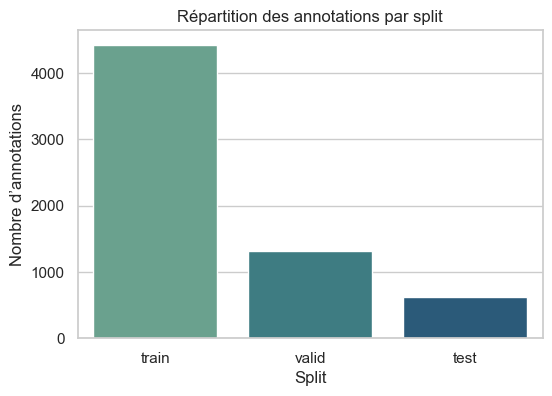

📂 Répartition des annotations par split :
split
train    4424
valid    1312
test      618
Name: count, dtype: int64


In [ ]:
split_counts = df["split"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")
plt.title("Répartition des annotations par split")
plt.xlabel("Split")
plt.ylabel("Nombre d’annotations")
plt.show()

print(split_counts)


In [8]:
# === Add names for the class ID
classes = {
    0: "Running",
    1: "Walking",
    2: "Laying_down",
    3: "Not_defined",
    4: "Seated",
    5: "Stands"
}

df["class_name"] = df["class_id"].map(classes)

There is 5 different posture : 
| Column      | Description |
|------------|-------------|
| `0` | The person is running |
| `1` | The person is walking |
| `2` | Laying_down |
| `3`    | Not_defined |
| `4`   | Seated |
| `5`   | Stands |

C:\Users\robin\AppData\Local\Temp\ipykernel_18724\719865911.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=annotations_per_class.index, y=annotations_per_class.values, palette="crest")


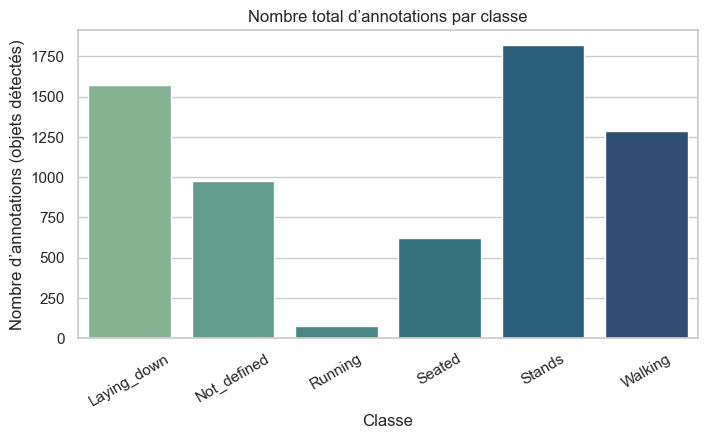

C:\Users\robin\AppData\Local\Temp\ipykernel_18724\719865911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=images_per_class.index, y=images_per_class.values, palette="viridis")


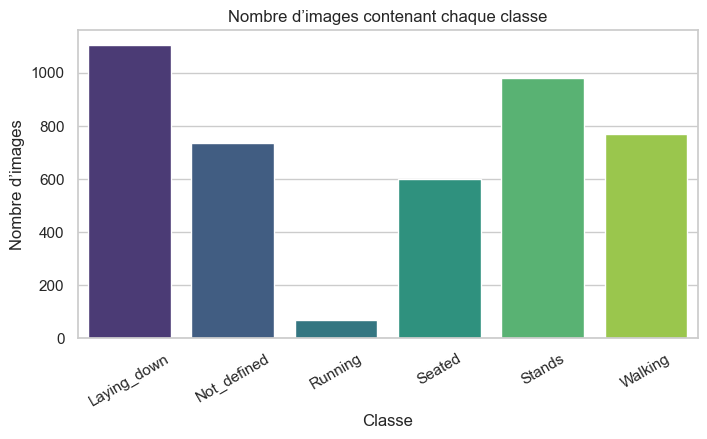

Number of mean object by images: 3.22


In [ ]:
# Analyse of the repartition of Classe ID

# Number of annotation / classes 
annotations_per_class = df["class_name"].value_counts().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=annotations_per_class.index, y=annotations_per_class.values, palette="crest")
plt.title("Nombre total d’annotations par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d’annotations (objets détectés)")
plt.xticks(rotation=30)
plt.show()

# Number of annotation / images 
images_per_class = df.groupby("class_name")["file"].nunique().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=images_per_class.index, y=images_per_class.values, palette="viridis")
plt.title("Nombre d’images contenant chaque classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d’images")
plt.xticks(rotation=30)
plt.show()

objects_per_image = df.groupby("file").size()
print(f"Number of mean object by images: {objects_per_image.mean():.2f}")


In [ ]:
# === 5. Statistiques descriptives ===
quant_vars = ["x_center", "y_center", "width", "height"]
print("=== Statistiques descriptives des variables quantitatives ===")
print(df[quant_vars].describe().T)


=== Statistiques descriptives des variables quantitatives ===
           count      mean       std       min       25%       50%       75%  \
x_center  6354.0  0.501729  0.241245  0.012240  0.305729  0.492969  0.688216   
y_center  6354.0  0.415600  0.240463  0.013889  0.212037  0.392593  0.571759   
width     6354.0  0.024552  0.018547  0.003646  0.012500  0.019271  0.030729   
height    6354.0  0.054299  0.030165  0.009259  0.033333  0.046296  0.065741   

               max  
x_center  0.996615  
y_center  0.988889  
width     0.183854  
height    0.312037  


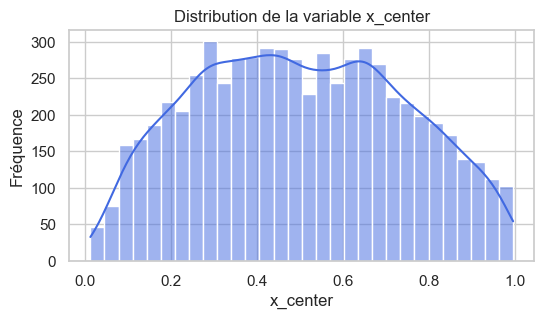

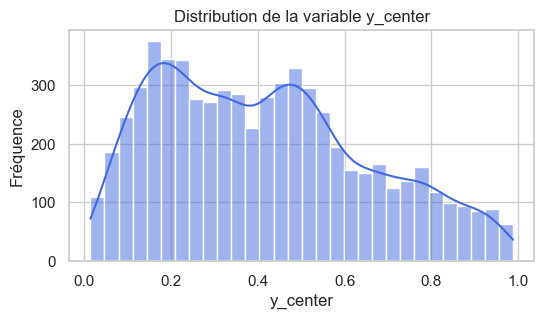

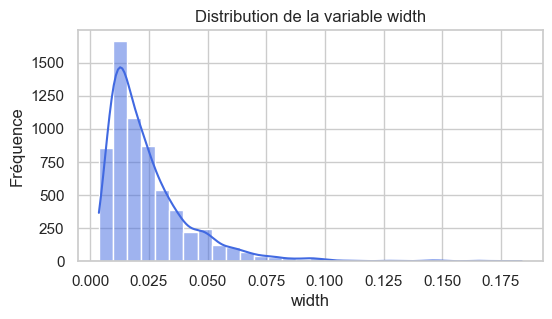

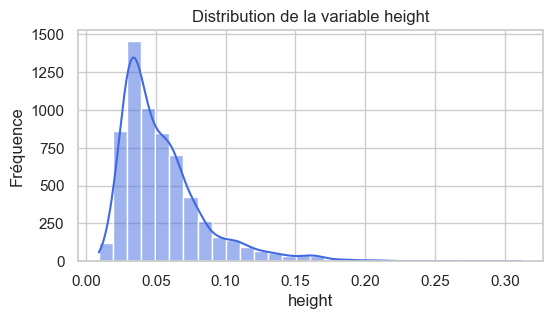

In [ ]:
# === 6. Distribution des variables quantitatives ===
for var in quant_vars:
    plt.figure(figsize=(6,3))
    sns.histplot(df[var], kde=True, bins=30, color="royalblue")
    plt.title(f"Distribution de la variable {var}")
    plt.xlabel(var)
    plt.ylabel("Fréquence")
    plt.show()


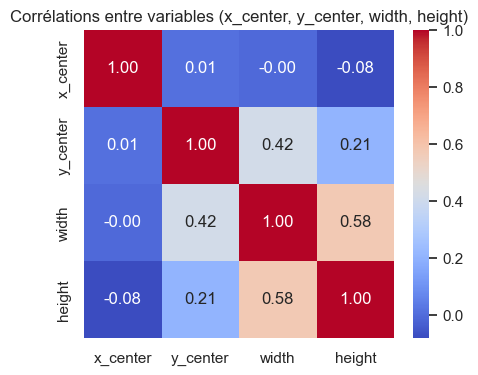

          x_center  y_center     width    height
x_center  1.000000  0.010653 -0.004375 -0.079775
y_center  0.010653  1.000000  0.416885  0.205746
width    -0.004375  0.416885  1.000000  0.575957
height   -0.079775  0.205746  0.575957  1.000000


In [ ]:
# === 7. Corrélations entre variables ===
correlations = df[quant_vars].corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations entre variables (x_center, y_center, width, height)")
plt.show()

print(correlations)
